# Mais parâmetros não deixam o modelo melhor

Treinei duas redes para ler dígitos escritos à mão. As duas passaram de 97% de acurácia no teste do MNIST.

Depois mostrei pra elas dez dígitos escritos à mão por outra pessoa, que nunca estiveram na base de treino. Uma delas acertou 4 de 10.

Esse notebook é o passo a passo desse teste. A pergunta que eu queria responder: **para imagem, qual arquitetura entrega mais acerto por parâmetro gasto?**

O roteiro:

1. duas arquiteturas (MLP e CNN) treinadas do zero, com o código completo
2. contagem de parâmetros de cada uma, separando extração de características de classificação
3. acurácia no teste oficial do MNIST e acertos em dígitos fora da distribuição de treino
4. no final, o que muda quando eu jogo data augmentation no problema

Tempo de execução: uns 45 minutos em CPU.

## Preparando o terreno

Nada de exótico aqui: TensorFlow, NumPy, Pillow para ler os PNGs e pandas para montar as tabelas.

A semente fixa é importante. Sem ela, cada execução inicializa os pesos de um jeito diferente e os números mudam um pouco toda vez, o que atrapalha na hora de comparar modelos.

In [1]:
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Input, Dense, Conv2D, MaxPooling2D, Flatten,
                                     Reshape, RandomRotation, RandomTranslation,
                                     RandomZoom)
from PIL import Image

# semente fixa: garante que rodar o notebook duas vezes dá o mesmo resultado
SEMENTE = 42
tf.keras.utils.set_random_seed(SEMENTE)

print("TensorFlow", tf.__version__)

TensorFlow 2.21.0


### Os dados de treino

MNIST: 60 mil imagens para treinar, 10 mil para testar. Cada uma é 28x28 pixels em escala de cinza.

Duas coisas acontecem aqui. Primeiro eu divido os pixels por 255, para trazer tudo para o intervalo de 0 a 1 (rede neural aprende melhor com valores nessa escala). Depois transformo os rótulos em vetores one-hot: o dígito 4 vira `[0,0,0,0,1,0,0,0,0,0]`, que é o formato que a camada de saída com softmax espera.

In [2]:
(x_treino, y_treino), (x_teste, y_teste) = tf.keras.datasets.mnist.load_data()

# normaliza os pixels de [0, 255] para [0, 1]
x_treino = x_treino.astype("float32") / 255.0
x_teste = x_teste.astype("float32") / 255.0

# rotulos viram vetores one-hot (o digito 4 vira [0,0,0,0,1,0,0,0,0,0])
y_treino_oh = tf.keras.utils.to_categorical(y_treino, 10)
y_teste_oh = tf.keras.utils.to_categorical(y_teste, 10)

print(f"treino: {x_treino.shape[0]:>6} imagens de {x_treino.shape[1]}x{x_treino.shape[2]}")
print(f"teste:  {x_teste.shape[0]:>6} imagens")

treino:  60000 imagens de 28x28
teste:   10000 imagens


## Os dois conjuntos de teste

Além do teste padrão do MNIST, eu tenho dois conjuntos pequenos, de dez dígitos cada, que vieram junto com um exercício da faculdade:

- **conjunto 1**: dez dígitos que foram copiados da própria base MNIST
- **conjunto 2**: dez dígitos escritos à mão por outra pessoa, que não fazem parte do MNIST

Esse segundo conjunto é o que interessa. Ele simula o que acontece quando o modelo sai do laboratório e encontra dados do mundo real, escritos por alguém com outra caligrafia.

In [3]:
PASTA_RN = Path("RN/RN")   # as 20 imagens que vieram junto com o exercicio

NOMES = ["zero0", "um1", "dois2", "tres3", "quatro4",
         "cinco5", "seis6", "sete7", "oito8", "nove9"]


def carrega_conjunto(sufixo):
    """Le os 10 PNGs de um conjunto e devolve um array (10, 28, 28) normalizado."""
    imagens = []
    for nome in NOMES:
        caminho = PASTA_RN / f"{nome}{sufixo}.png"
        img = Image.open(caminho).convert("L").resize((28, 28))
        imagens.append(np.array(img, dtype="float32") / 255.0)
    return np.stack(imagens)


conjunto_mnist = carrega_conjunto("")    # digitos tirados da propria base MNIST
conjunto_novo = carrega_conjunto("b")    # digitos de outra caligrafia
GABARITO = np.arange(10)                 # os dois conjuntos estao na ordem 0..9

print(f"conjunto 1: {conjunto_mnist.shape}")
print(f"conjunto 2: {conjunto_novo.shape}")

conjunto 1: (10, 28, 28)
conjunto 2: (10, 28, 28)


Vamos olhar para eles antes de qualquer coisa. Metade dos problemas de machine learning aparece quando você simplesmente plota os dados.

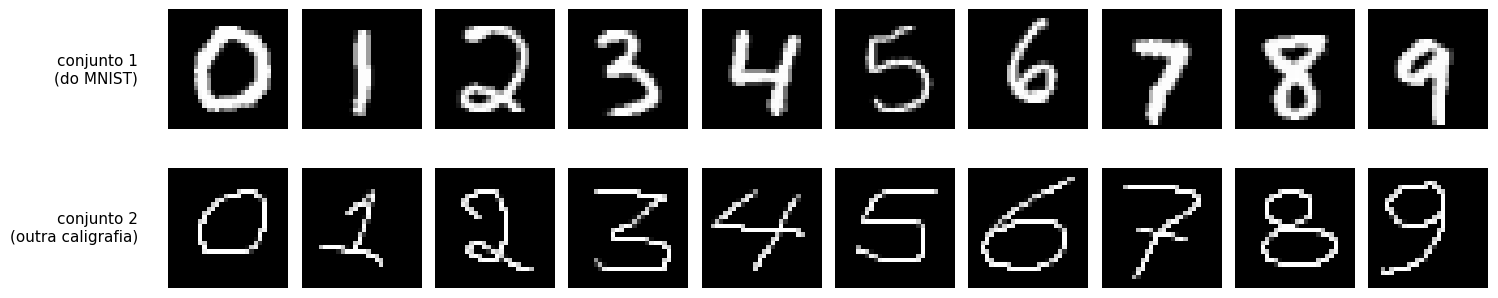

In [4]:
fig, axs = plt.subplots(2, 10, figsize=(15, 3.6))

for coluna in range(10):
    axs[0, coluna].imshow(conjunto_mnist[coluna], cmap="gray", vmin=0, vmax=1)
    axs[1, coluna].imshow(conjunto_novo[coluna], cmap="gray", vmin=0, vmax=1)
    for linha in range(2):
        axs[linha, coluna].axis("off")

fig.text(0.09, 0.72, "conjunto 1\n(do MNIST)", ha="right", va="center", fontsize=11)
fig.text(0.09, 0.28, "conjunto 2\n(outra caligrafia)", ha="right", va="center", fontsize=11)
plt.tight_layout()
plt.subplots_adjust(left=0.11)
plt.show()

A diferença salta aos olhos: o traço de baixo é bem mais fino. Dá pra medir isso em vez de confiar no olho.

In [5]:
def fracao_de_tinta(imagens):
    """Percentual de pixels que fazem parte do traco (acima de 20% de brilho)."""
    return (imagens > 0.2).mean(axis=(1, 2))


tabela_tinta = pd.DataFrame({
    "conjunto": ["MNIST (2000 amostras)", "conjunto 1", "conjunto 2"],
    "fração de tinta": [
        fracao_de_tinta(x_treino[:2000]).mean(),
        fracao_de_tinta(conjunto_mnist).mean(),
        fracao_de_tinta(conjunto_novo).mean(),
    ],
})
tabela_tinta["fração de tinta"] = tabela_tinta["fração de tinta"].round(3)
tabela_tinta

,conjunto,fração de tinta
0,MNIST (2000 amostras),0.161
1,conjunto 1,0.167
2,conjunto 2,0.083


O conjunto 2 tem por volta da metade da tinta do MNIST. Guarde esse número, ele volta no final.

## MLP e CNN: a diferença que importa

Essa é a parte conceitual, e vale a pena entender antes de olhar qualquer resultado.

**A MLP achata a imagem.** Um quadro de 28x28 vira uma fila de 784 números, e cada número dessa fila é ligado a cada neurônio da camada seguinte. Funciona, mas tem um custo escondido: ao achatar, os pixels que eram vizinhos deixam de ser vizinhos. Dois pixels que estavam um em cima do outro, formando um pedaço de traço vertical, terminam a 28 posições de distância na fila. A informação de que eles eram próximos simplesmente some, e a rede precisa reconstruir isso na marra, a partir dos exemplos.

**A CNN não achata nada no começo.** Ela desliza filtros pequenos (3x3) pela imagem toda, procurando padrões locais: uma borda, uma curva, um canto. E aqui está o detalhe que muda a conta: o mesmo filtro é reaplicado em todas as posições. São 9 pesos varrendo a imagem inteira, em vez de um peso dedicado para cada pixel de cada posição.

Consequência prática: a CNN aprende "existe uma borda vertical aqui" de um jeito que continua valendo se o traço andar três pixels para o lado. A MLP não tem isso de graça.

Chega de teoria. Vamos montar as duas e ver no que dá.

### As duas arquiteturas em código

As funções abaixo montam os modelos.

In [6]:
def monta_mlp(transformacoes=()):
    """MLP: achata a imagem em 784 numeros e liga todos com todos."""
    modelo = Sequential([
        Input(shape=(28, 28)),
        Reshape((28, 28, 1)),
        *transformacoes,
        Flatten(),
        Dense(256, activation="tanh"),
        Dense(128, activation="tanh"),
        Dense(10, activation="softmax"),
    ])
    modelo.compile(loss="categorical_crossentropy", optimizer="adam",
                   metrics=["accuracy"])
    return modelo


def monta_cnn(transformacoes=()):
    """CNN: filtros deslizam pela imagem procurando bordas, curvas e cantos."""
    modelo = Sequential([
        Input(shape=(28, 28)),
        Reshape((28, 28, 1)),
        *transformacoes,
        Conv2D(32, (3, 3), activation="relu"),
        MaxPooling2D((2, 2)),
        Conv2D(64, (3, 3), activation="relu"),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(128, activation="relu"),
        Dense(10, activation="softmax"),
    ])
    modelo.compile(loss="categorical_crossentropy", optimizer="adam",
                   metrics=["accuracy"])
    return modelo

## Contando os parâmetros

Antes de treinar, vamos ver quanto cada arquitetura custa. Eu separo os parâmetros em dois grupos, porque isso conta uma história que o número total esconde:

- **extração de características**: as camadas convolucionais, que descobrem o que tem na imagem
- **classificação**: as camadas densas no final, que decidem qual dígito é

In [7]:
def perfil_de_parametros(modelo, nome):
    """Separa os parametros entre extracao de caracteristicas e classificacao."""
    convolucao = sum(c.count_params() for c in modelo.layers if isinstance(c, Conv2D))
    densas = sum(c.count_params() for c in modelo.layers if isinstance(c, Dense))
    return {
        "modelo": nome,
        "extração (conv)": convolucao,
        "classificação (densas)": densas,
        "total": modelo.count_params(),
    }


perfil = pd.DataFrame([
    perfil_de_parametros(monta_mlp(), "MLP"),
    perfil_de_parametros(monta_cnn(), "CNN"),
])
perfil

,modelo,extração (conv),classificação (densas),total
0,MLP,0,235146,235146
1,CNN,18816,206218,225034


Primeira surpresa: **a CNN tem menos parâmetros que a MLP**, mesmo tendo mais camadas.

E olha onde ela gasta. As convoluções, que são a parte que de fato olha a imagem, custam só 18.816 pesos. Todo o resto é a camada densa do final, que apenas decide o que fazer com as características já extraídas.

Vamos ver o detalhe camada por camada.

In [8]:
monta_cnn().summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape_2 (Reshape)             │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

## Treinando as duas

Mesma base, mesma semente, mesmo otimizador. A única coisa que muda é a arquitetura.

A CNN roda menos épocas porque ela converge bem mais rápido: 5 épocas já bastam para passar de 98%, enquanto a MLP precisa de 15 para chegar perto.

In [9]:
def acertos_no_conjunto(modelo, imagens):
    """Roda o modelo nas 10 imagens e conta quantas ele acertou."""
    previsto = np.argmax(modelo.predict(imagens, verbose=0), axis=1)
    return int((previsto == GABARITO).sum()), previsto


def roda_experimento(nome, construtor, epocas, fabrica_transformacoes=None):
    """Treina um modelo e mede tudo que interessa para o comparativo.

    fabrica_transformacoes e uma FUNCAO, nao uma lista pronta. As camadas
    aleatorias precisam ser criadas depois do set_random_seed abaixo, senao
    elas herdam a semente do que rodou antes e o resultado deixa de ser
    reproduzivel.
    """
    tf.keras.utils.set_random_seed(SEMENTE)
    transformacoes = fabrica_transformacoes() if fabrica_transformacoes else ()
    modelo = construtor(transformacoes)

    inicio = time.time()
    modelo.fit(x_treino, y_treino_oh, epochs=epocas, batch_size=128, verbose=0)
    duracao = time.time() - inicio

    perda, acuracia = modelo.evaluate(x_teste, y_teste_oh, verbose=0)
    acertos_c1, _ = acertos_no_conjunto(modelo, conjunto_mnist)
    acertos_c2, previsto_c2 = acertos_no_conjunto(modelo, conjunto_novo)

    print(f"{nome:<22} {duracao:5.0f}s  |  MNIST {acuracia:.4f}  |  "
          f"conj.1 {acertos_c1}/10  |  conj.2 {acertos_c2}/10")

    return {
        "modelo": nome,
        "parâmetros": modelo.count_params(),
        "épocas": epocas,
        "tempo (s)": round(duracao),
        "perda (MNIST)": round(float(perda), 4),
        "acurácia (MNIST)": round(float(acuracia), 4),
        "conjunto 1": acertos_c1,
        "conjunto 2": acertos_c2,
        "previsões conj.2": previsto_c2,
    }


resultados = [
    roda_experimento("MLP", monta_mlp, epocas=15),
    roda_experimento("CNN", monta_cnn, epocas=5),
]

MLP                       32s  |  MNIST 0.9767  |  conj.1 10/10  |  conj.2 4/10


CNN                       74s  |  MNIST 0.9869  |  conj.1 10/10  |  conj.2 8/10


## Os resultados

In [10]:
def tabela_de(resultados):
    """Monta a tabela comparativa a partir da lista de resultados."""
    t = pd.DataFrame(resultados).drop(columns=["previsões conj.2"])
    t["conjunto 1"] = t["conjunto 1"].astype(str) + "/10"
    t["conjunto 2"] = t["conjunto 2"].astype(str) + "/10"
    return t


tabela_de(resultados)

,modelo,parâmetros,épocas,tempo (s),perda (MNIST),acurácia (MNIST),conjunto 1,conjunto 2
0,MLP,235146,15,32,0.0861,0.9767,10/10,4/10
1,CNN,225034,5,74,0.0389,0.9869,10/10,8/10


### O que salta da tabela

**As duas vão bem no MNIST e no conjunto 1.** Acurácia acima de 97% e 10 acertos em 10. Se o teste parasse aqui, eu diria que os dois modelos estão prontos.

**No conjunto 2 a distância aparece.** A CNN acerta 8 de 10, a MLP acerta 4. O dobro, com menos parâmetros.

**A MLP treinou mais rápido no relógio**, mas isso engana. Ela precisou de 15 épocas contra 5 da CNN. Cada época da CNN custa mais porque tem convolução no meio, só que ela aprende tanto por época que compensa.

E vale reforçar o que esses 4 de 10 significam: a MLP tem 97,67% de acurácia no teste do MNIST. Se eu tivesse olhado só para esse número, mandava o modelo para produção achando que estava tudo certo.

### Onde cada modelo errou

A tabela acima mostra quantos acertou. Essa aqui mostra o que ele respondeu em cada dígito.

In [11]:
def detalhe_de(resultados):
    """Tabela com a previsao de cada modelo para cada um dos 10 digitos."""
    d = pd.DataFrame(
        [r["previsões conj.2"] for r in resultados],
        index=[r["modelo"] for r in resultados],
        columns=[f"{digito}" for digito in range(10)],
    )
    d["acertos"] = [f'{r["conjunto 2"]}/10' for r in resultados]
    return d


def marca_erro(coluna):
    """Pinta de vermelho as previsoes que nao batem com o gabarito."""
    if coluna.name == "acertos":
        return ["" for _ in coluna]
    esperado = int(coluna.name)
    return ["color: #c0392b; font-weight: bold" if v != esperado else ""
            for v in coluna]


detalhe_de(resultados).style.apply(marca_erro).set_caption(
    "Colunas = dígito real. Valores em vermelho são erros.")

,0,1,2,3,4,5,6,7,8,9,acertos
MLP,0,2,2,3,7,5,5,2,3,3,4/10
CNN,0,1,2,3,4,5,5,7,8,3,8/10


O 7 desse conjunto está escrito com um corte horizontal no meio da haste, um jeito de escrever usado em vários países. Pelo comportamento dos modelos dá pra desconfiar que esse formato é pouco frequente na base de treino.

A MLP erra esse dígito e chuta 2. Faz sentido: a haste de cima somada ao corte no meio produz uma distribuição de pixels que, para quem só viu 7 sem corte, lembra mesmo um 2. A CNN acerta. Ela não está comparando pixel por pixel, está procurando a relação entre uma linha horizontal em cima e uma diagonal descendente, e essa relação continua lá com ou sem o corte no meio.

O 6 as duas erram, sempre virando 5. Volto nele no final.

### Acerto por parâmetro

Se o assunto é eficiência, o número total de parâmetros sozinho não diz nada. O que interessa é quanto acerto cada modelo entrega pelo tamanho que tem.

In [12]:
def tabela_eficiencia(resultados):
    """Relaciona tamanho do modelo com o que ele entrega."""
    e = pd.DataFrame(resultados)[["modelo", "parâmetros", "acurácia (MNIST)",
                                  "conjunto 2"]].copy()
    # quanto de acuracia o modelo entrega a cada 100 mil parametros
    e["acurácia por 100k params"] = (
        e["acurácia (MNIST)"] / (e["parâmetros"] / 100_000)
    ).round(4)
    return e


tabela_eficiencia(resultados)

,modelo,parâmetros,acurácia (MNIST),conjunto 2,acurácia por 100k params
0,MLP,235146,0.9767,4,0.4154
1,CNN,225034,0.9869,8,0.4386


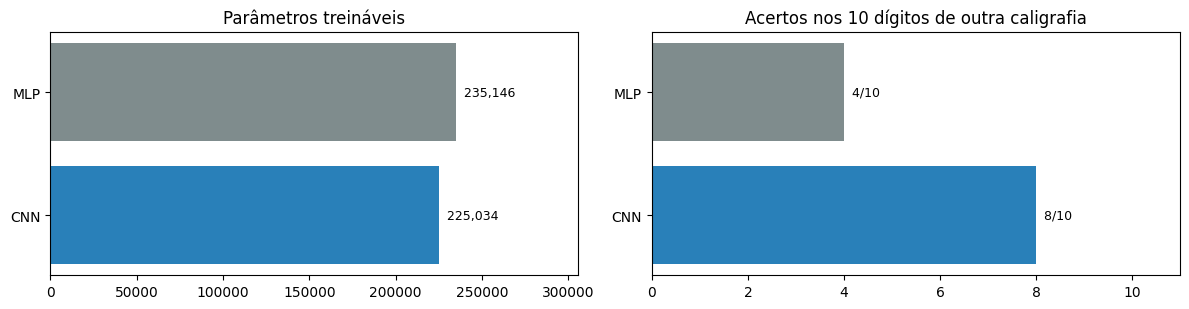

In [13]:
fig, (esq, dir) = plt.subplots(1, 2, figsize=(12, 3.2))

nomes = [r["modelo"] for r in resultados]
cores = ["#7f8c8d", "#2980b9"]

esq.barh(nomes, [r["parâmetros"] for r in resultados], color=cores)
esq.set_title("Parâmetros treináveis")
esq.invert_yaxis()
esq.set_xlim(0, max(r["parâmetros"] for r in resultados) * 1.3)
for i, r in enumerate(resultados):
    esq.text(r["parâmetros"], i, f'  {r["parâmetros"]:,}', va="center", fontsize=9)

dir.barh(nomes, [r["conjunto 2"] for r in resultados], color=cores)
dir.set_title("Acertos nos 10 dígitos de outra caligrafia")
dir.invert_yaxis()
dir.set_xlim(0, 11)
for i, r in enumerate(resultados):
    dir.text(r["conjunto 2"], i, f'  {r["conjunto 2"]}/10', va="center", fontsize=9)

plt.tight_layout()
plt.show()

Os dois gráficos lado a lado resumem o notebook inteiro: a barra de cima é maior em parâmetros e menor em acerto.

A diferença não está em quantos pesos existem, está em como eles se organizam. A MLP gasta 235 mil pesos sem ter nenhum mecanismo dedicado a entender vizinhança de pixel. A CNN resolve isso com 18.816 pesos de convolução e sobra dinheiro no orçamento.

## E se eu ajudar a MLP?

Até aqui a comparação foi arquitetura contra arquitetura, nas mesmas condições. Mas a MLP errar 6 de 10 numa caligrafia diferente não é só falta de convolução: é também que ela nunca viu, no treino, um dígito escrito de outro jeito.

Dá pra atacar isso sem trocar uma linha da arquitetura, usando **data augmentation**.

A ideia: a cada época, cada imagem de treino é girada, deslocada e ampliada por uma quantidade aleatória. O modelo nunca vê duas vezes exatamente a mesma imagem, então ele para de se apoiar no enquadramento exato do MNIST.

Dois detalhes que importam:

1. essas camadas ficam ativas **só no treino**. Na hora de prever, o Keras desliga elas sozinho, e a imagem de teste chega intacta.
2. o aprendizado por época fica mais lento, porque a tarefa ficou mais difícil. Por isso eu triplico o número de épocas.

In [14]:
def camadas_de_augmentation():
    """Transformacoes aleatorias aplicadas so durante o treino.

    A semente explicita em cada camada deixa o experimento reproduzivel.
    """
    return [
        RandomRotation(0.08, seed=SEMENTE),           # gira ate +/- 29 graus
        RandomTranslation(0.10, 0.10, seed=SEMENTE),  # desloca ate 10% (uns 2,8 pixels)
        RandomZoom(0.10, seed=SEMENTE),               # amplia ou reduz ate 10%
    ]


# mesmas arquiteturas, mesma semente, so que agora com as transformacoes plugadas
resultados += [
    roda_experimento("MLP + augmentation", monta_mlp, epocas=45,
                     fabrica_transformacoes=camadas_de_augmentation),
    roda_experimento("CNN + augmentation", monta_cnn, epocas=15,
                     fabrica_transformacoes=camadas_de_augmentation),
]

MLP + augmentation       322s  |  MNIST 0.9820  |  conj.1 10/10  |  conj.2 9/10


CNN + augmentation       236s  |  MNIST 0.9802  |  conj.1 10/10  |  conj.2 9/10


> **Nota de reprodutibilidade.** Repare que eu passo `camadas_de_augmentation` sem os parênteses, ou seja, mando a função e não a lista pronta. As camadas aleatórias precisam nascer depois do `set_random_seed`, lá dentro da função. Se eu criasse elas antes, herdariam a semente do que tivesse rodado antes e o notebook devolveria um número diferente a cada execução. Descobri isso do jeito chato, rodando duas vezes e vendo o resultado mudar.

### O comparativo completo

In [15]:
tabela_de(resultados)

,modelo,parâmetros,épocas,tempo (s),perda (MNIST),acurácia (MNIST),conjunto 1,conjunto 2
0,MLP,235146,15,32,0.0861,0.9767,10/10,4/10
1,CNN,225034,5,74,0.0389,0.9869,10/10,8/10
2,MLP + augmentation,235146,45,322,0.0588,0.9820,10/10,9/10
3,CNN + augmentation,225034,15,236,0.0608,0.9802,10/10,9/10


In [16]:
detalhe_de(resultados).style.apply(marca_erro).set_caption(
    "Colunas = dígito real. Valores em vermelho são erros.")

,0,1,2,3,4,5,6,7,8,9,acertos
MLP,0,2,2,3,7,5,5,2,3,3,4/10
CNN,0,1,2,3,4,5,5,7,8,3,8/10
MLP + augmentation,0,1,2,3,4,5,5,7,8,9,9/10
CNN + augmentation,0,1,2,3,4,5,5,7,8,9,9/10


### O que o augmentation mudou

**A MLP saltou de 4 para 9 acertos.** Nenhum peso a mais, nenhuma camada nova, mesma arquitetura. Só treinar com versões giradas e deslocadas das mesmas imagens. O preço foi tempo: quase dez vezes mais treino.

**A CNN foi de 8 para 9**, um ganho bem menor. Ela já estava perto do teto dessas dez imagens.

**Os dois modelos com augmentation terminaram idênticos** nas dez imagens, errando só o 6. Chegaram no mesmo lugar por caminhos diferentes.

**E repara no custo dessa igualdade.** A CNN sem ajuda nenhuma já entregava 8 de 10 gastando cerca de um quarto do tempo que a MLP com augmentation precisou para chegar a 9. As duas rotas funcionam, resolver na arquitetura e resolver no dado, mas uma delas sai bem mais barata.

**Mas tem um número esquisito nessa tabela.** A acurácia da CNN no MNIST caiu de 98,69% para 98,02% depois do augmentation, com a perda subindo junto. Isso é estranho: augmentation costuma funcionar como regularizador e melhorar a generalização, não piorar.

Então vamos nos aprofundar e medir!

## O número esquisito da CNN

A hipótese é que 15 épocas seja pouco quando o augmentation deixa a tarefa mais difícil. Se for isso, treinar mais tempo deve resolver.

Em vez de treinar várias vezes com número de épocas diferente, treino uma vez por 45 épocas e meço a acurácia ao fim de cada uma. Assim eu vejo a curva inteira de uma vez.

In [17]:
class AcompanhaEpocas(tf.keras.callbacks.Callback):
    """Mede acuracia no MNIST e acerto na caligrafia nova ao fim de cada epoca."""

    def __init__(self):
        super().__init__()
        self.historico = []

    def on_epoch_end(self, epoca, logs=None):
        _, acuracia = self.model.evaluate(x_teste, y_teste_oh, verbose=0)
        acertos, _ = acertos_no_conjunto(self.model, conjunto_novo)
        self.historico.append({
            "época": epoca + 1,
            "acurácia (MNIST)": round(float(acuracia), 4),
            "conjunto 2": acertos,
        })


tf.keras.utils.set_random_seed(SEMENTE)
modelo_longo = monta_cnn(camadas_de_augmentation())
acompanha = AcompanhaEpocas()
modelo_longo.fit(x_treino, y_treino_oh, epochs=45, batch_size=128, verbose=0,
                 callbacks=[acompanha])

curva = pd.DataFrame(acompanha.historico)

# a referencia e a CNN sem augmentation, que ja treinou la em cima
acuracia_sem_aug = next(r["acurácia (MNIST)"] for r in resultados if r["modelo"] == "CNN")
melhor = curva.loc[curva["acurácia (MNIST)"].idxmax()]

print(f"CNN sem augmentation:            {acuracia_sem_aug:.4f}")
print(f"CNN com augmentation, época 15:  {curva.loc[14, 'acurácia (MNIST)']:.4f}")
print(f"CNN com augmentation, época 16:  {curva.loc[15, 'acurácia (MNIST)']:.4f}")
print(f"melhor de todas (época {int(melhor['época']):>2}):      {melhor['acurácia (MNIST)']:.4f}")

CNN sem augmentation:            0.9869
CNN com augmentation, época 15:  0.9802
CNN com augmentation, época 16:  0.9886
melhor de todas (época 32):      0.9925


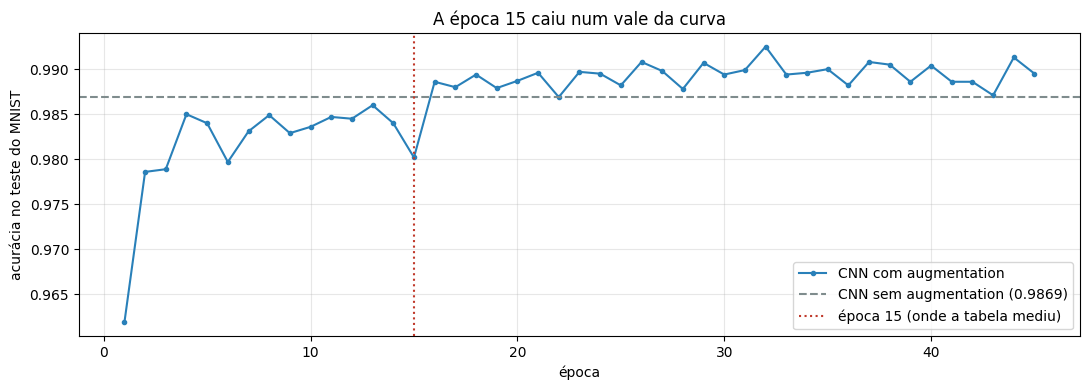

In [18]:
fig, eixo = plt.subplots(figsize=(11, 4))

eixo.plot(curva["época"], curva["acurácia (MNIST)"], marker="o", markersize=3,
          color="#2980b9", label="CNN com augmentation")
eixo.axhline(acuracia_sem_aug, color="#7f8c8d", linestyle="--",
             label=f"CNN sem augmentation ({acuracia_sem_aug:.4f})")
eixo.axvline(15, color="#c0392b", linestyle=":", linewidth=1.5,
             label="época 15 (onde a tabela mediu)")

eixo.set_xlabel("época")
eixo.set_ylabel("acurácia no teste do MNIST")
eixo.set_title("A época 15 caiu num vale da curva")
eixo.legend(loc="lower right")
eixo.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### O que a curva mostra

**A época 15 caiu num vale.** Época 13 deu 98,60%, época 14 deu 98,40%, época 15 deu 98,02% e época 16 já voltou para 98,86%. A tabela anterior mediu exatamente no pior ponto daquela vizinhança.

**Com épocas suficientes o augmentation ganha do baseline.** Da época 16 em diante a curva fica quase sempre acima da linha tracejada, e o melhor ponto chega a 99,25% contra 98,69% sem augmentation. Ou seja, o augmentation funciona mesmo na CNN, ele só precisava de mais tempo para pagar o investimento.

**E a lição que eu acho mais útil:** a curva oscila bastante de uma época para a outra, quase meio ponto percentual entre épocas vizinhas. Ler um único ponto dela e tirar conclusão é frágil. Foi o que eu fiz na primeira tabela, e a conclusão saiu invertida.

Uma tentação aqui seria voltar na tabela e trocar 15 por 32, que foi o melhor número. Isso seria escolher o resultado olhando para o conjunto de teste, o que é uma forma silenciosa de vazar informação. O jeito honesto é separar um conjunto de validação e parar por ele, com early stopping, deixando o teste intocado até o fim.

Então vamos nos aprofundar mais um vez!

## O jeito honesto: early stopping

A regra é simples: **o conjunto de teste não pode participar de nenhuma decisão**. Nem da escolha de arquitetura, nem de hiperparâmetro, nem de quando parar de treinar. Ele existe para uma coisa só, estimar o desempenho no final.

Então eu separo um pedaço do treino para validação, monitoro a acurácia nele a cada época, e deixo o `EarlyStopping` decidir a hora de parar. O `restore_best_weights=True` faz o modelo voltar para os pesos da melhor época de validação, e não os da última.

Duas observações antes de rodar:

1. os modelos aqui treinam com 54 mil imagens em vez de 60 mil, porque 6 mil foram para a validação. É uma desvantagem em relação às tabelas anteriores, e ainda assim é o jeito certo de fazer.
2. deixo até 45 épocas disponíveis, com paciência de 10. Quem decide quando parar é a validação, não eu.

In [19]:
from tensorflow.keras.callbacks import EarlyStopping

# separa 10% do treino para validacao. O teste do MNIST continua intocado.
N_VALIDACAO = 6000
x_val, y_val = x_treino[:N_VALIDACAO], y_treino_oh[:N_VALIDACAO]
x_treino_menor = x_treino[N_VALIDACAO:]
y_treino_menor = y_treino_oh[N_VALIDACAO:]


def roda_com_early_stopping(nome, construtor, epocas_maximas=45, paciencia=10):
    """Treina ate a validacao parar de melhorar, sem olhar para o teste."""
    tf.keras.utils.set_random_seed(SEMENTE)
    modelo = construtor(camadas_de_augmentation())

    parada = EarlyStopping(monitor="val_accuracy", patience=paciencia,
                           restore_best_weights=True)

    inicio = time.time()
    historico = modelo.fit(x_treino_menor, y_treino_menor,
                           validation_data=(x_val, y_val),
                           epochs=epocas_maximas, batch_size=128,
                           verbose=0, callbacks=[parada])
    duracao = time.time() - inicio

    epocas_rodadas = len(historico.history["val_accuracy"])
    epoca_escolhida = int(np.argmax(historico.history["val_accuracy"])) + 1

    # so agora, com o treino encerrado, o teste entra em cena
    _, acuracia = modelo.evaluate(x_teste, y_teste_oh, verbose=0)
    acertos_c2, _ = acertos_no_conjunto(modelo, conjunto_novo)

    print(f"{nome:<22} parou na época {epocas_rodadas:>2}, "
          f"melhor validação na {epoca_escolhida:>2}  |  "
          f"teste {acuracia:.4f}  |  conj.2 {acertos_c2}/10  |  {duracao:.0f}s")

    return {
        "modelo": nome,
        "épocas rodadas": epocas_rodadas,
        "época escolhida": epoca_escolhida,
        "acurácia (MNIST)": round(float(acuracia), 4),
        "conjunto 2": acertos_c2,
    }


resultados_es = [
    roda_com_early_stopping("MLP + augmentation", monta_mlp),
    roda_com_early_stopping("CNN + augmentation", monta_cnn),
]

MLP + augmentation     parou na época 33, melhor validação na 23  |  teste 0.9808  |  conj.2 10/10  |  189s


CNN + augmentation     parou na época 42, melhor validação na 32  |  teste 0.9931  |  conj.2 10/10  |  650s


In [20]:
# compara o protocolo arbitrario (numero de epocas no chute) com o early stopping
arbitrario = {r["modelo"]: r for r in resultados}

comparativo = pd.DataFrame([
    {
        "modelo": r["modelo"],
        "épocas (chute)": arbitrario[r["modelo"]]["épocas"],
        "acurácia (chute)": arbitrario[r["modelo"]]["acurácia (MNIST)"],
        "conj.2 (chute)": f'{arbitrario[r["modelo"]]["conjunto 2"]}/10',
        "época (early stop)": r["época escolhida"],
        "acurácia (early stop)": r["acurácia (MNIST)"],
        "conj.2 (early stop)": f'{r["conjunto 2"]}/10',
    }
    for r in resultados_es
])
comparativo

,modelo,épocas (chute),acurácia (chute),conj.2 (chute),época (early stop),acurácia (early stop),conj.2 (early stop)
0,MLP + augmentation,45,0.9820,9/10,23,0.9808,10/10
1,CNN + augmentation,15,0.9802,9/10,32,0.9931,10/10


### O que o early stopping mostrou

**A CNN saltou de 98,02% para 99,31%.** Mesmo modelo, mesmo augmentation, mesma semente. A única diferença foi parar na hora certa em vez de num número redondo que eu escolhi no chute. E ela ainda treinou com menos dados aqui, 54 mil imagens em vez de 60 mil, porque 6 mil foram para a validação.

**Aqui está o detalhe que fecha o argumento:** o early stopping escolheu a época 32 para a CNN. A curva da seção anterior, aquela que eu montei olhando para o conjunto de teste, tinha apontado a época 32 como o melhor ponto. A validação chegou na mesma resposta sem nunca ver o teste. É exatamente para isso que ela serve, e é bom ver funcionando em vez de só repetir que funciona.

**Os dois modelos acertaram 10 de 10**, o primeiro placar perfeito do notebook. Cabe a ressalva: são dez imagens, então sair de 9 para 10 é um dígito só e pode ser sorte. O número em que eu confio mais é a acurácia no teste do MNIST, medida em 10 mil imagens, e lá o salto da CNN é grande demais para ser ruído.

**A MLP caiu de pouquinho**, de 98,20% para 98,08%. Era esperado, ela perdeu 10% dos dados de treino para a validação e parou na época 23 em vez de rodar as 45. Mesmo assim chegou nos mesmos 10 de 10.

## Conclusão

**Contar parâmetro não é medir capacidade.** As duas redes têm praticamente o mesmo tamanho (235 mil pesos contra 225 mil). Mesmo assim a CNN entrega acurácia maior no MNIST e o dobro de acertos na caligrafia nova, sem precisar de ajuda nenhuma. O que importa é como os pesos se organizam, não quantos são.

**Data augmentation é barato e resolve bastante coisa.** A MLP mais que dobrou o acerto no conjunto difícil sem ganhar um único peso novo. Quando não dá pra trocar a arquitetura, atacar o dado costuma render mais do que empilhar camada. O custo aparece no relógio, e não em memória.

Mas vale notar o que ele não cobre. As três transformações que usei mexem em posição, ângulo e escala, e nenhuma delas engrossa ou afina o traço. Aquela diferença de tinta que eu medi lá no começo (0,083 contra 0,161) atravessou o notebook inteiro sem ser tratada.

**Um ponto isolado da curva de treino não é um resultado.** A CNN com augmentation parecia ter piorado, e tinha só caído num vale bem na época em que resolvi medir. Trocar o chute por early stopping numa validação separada levou ela de 98,02% para 99,31%, e ainda escolheu sozinha a mesma época que eu tinha identificado espiando o teste. Se um número te surpreender, vale medir antes de escrever a explicação para ele.

**Acurácia alta no teste não quer dizer modelo pronto.** Todos os modelos passaram de 97% no MNIST. Na caligrafia de outra pessoa, o placar variou de 4 a 10 acertos em 10, dependendo da arquitetura e de como o treino foi conduzido. O teste padrão mede o quanto o modelo aprendeu aquela base específica, não o quanto ele funciona lá fora.

**E o 6 que parecia impossível.** Durante quase todo o notebook o 6 foi lido como 5, em todos os modelos, e eu cheguei a pensar que só coletando exemplos novos daria pra resolver. Os dois modelos com early stopping acertaram ele. Não era limite do dado, era modelo parado no lugar errado. Fica a lição de não declarar limite antes de esgotar o básico.